In [47]:
"""
FINUFFT
Here I provide a first try at getting FINUFFT to work. The first step is to install finufft on Tycho,
as far as I recall I simply did

pip install finufft
"""

import finufft
import paicos as pa
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm


# Load a snapshot and select spherical region (?)
# snap = pa.Snapshot('/lustre/astro/berlok/zoom-simulations-new-ics/halo_0003/adiabatic-mhd/zoom4_ics_v1/output', 247)
snap = pa.Snapshot(pa.data_dir, 247)
center = snap.Cat.Group['GroupPos'][0]
R200c = snap.Cat.Group['Group_R_Crit200'][0]
r_max = 1.0 * R200c
# index = pa.util.get_index_of_radial_range(snap['0_Coordinates'], center, 0., r_max)

widths = np.array([2e3, 2e3, 2e3], dtype=float)
index = pa.util.get_index_of_cubic_region(snap['0_Coordinates'], center, widths, snap.box)
snap = snap.select(index, parttype=0)



In [48]:
snap['0_Coordinates'].shape

(12515, 3)

In [49]:
snap['0_Coordinates'][:, 0]

<PaicosQuantity [398974.38664031, 398976.06220306, 398964.31625223, ...,
                 398188.35831544, 399801.08658404, 399808.65546007] arepo_length small_a / small_h>

In [50]:
M = snap['0_Coordinates'].shape[0]
# A simple example,
# https://finufft.readthedocs.io/en/latest/python.html#quick-start-examples
# https://finufft.readthedocs.io/en/latest/python.html#finufft.Plan


# k1 = 1.0 * 2 * np.pi
# k2 = 0.0 * 2 * np.pi
# k3 = 0.0 * 2 * np.pi

# the nonuniform points (rescaled to -1 to 1), should be -pi to pi?
# x = (snap['0_Coordinates'][:, 0] - center[0]).value / R200c.value
# y = (snap['0_Coordinates'][:, 1] - center[1]).value / R200c.value
# z = (snap['0_Coordinates'][:, 2] - center[2]).value / R200c.value

# I think it should be 0, 2pi

x = 2 * np.pi * (snap['0_Coordinates'][:, 0].value - ( center[0].value - widths[0]/2. )) / widths[0]
y = 2 * np.pi * (snap['0_Coordinates'][:, 1].value - ( center[1].value - widths[1]/2. )) / widths[1]
z = 2 * np.pi * (snap['0_Coordinates'][:, 2].value - ( center[2].value - widths[2]/2. )) / widths[2]

# # their complex strengths
# c = snap['0_Density'].value + 0.0j
c = (np.random.standard_normal(size=M)
     + 1J * 0.0)


In [51]:
grid_size = 10
# c = np.exp(1j*k1*x + 1j*k2*y + 1j*k3*z).real + 0.0j

# # desired number of Fourier modes

kx = np.arange(0, grid_size)*1.0
ky = np.arange(0, grid_size)*1.0
kz = np.arange(0, grid_size)*1.0

# kx = np.logspace(-2, 2, grid_size)*2*np.pi
# ky = np.logspace(-2, 2, grid_size)*2*np.pi
# kz = np.logspace(-2, 2, grid_size)*2*np.pi

kxx, kyy, kzz = np.meshgrid(kx, ky, kz)

kx = kxx.flatten()
ky = kyy.flatten()
kz = kzz.flatten()


# calculate the NUFFT
f = finufft.nufft3d3(x, y, z, c, kx, ky, kz)
k = np.sqrt(kx**2 + ky**2 + kz**2)
# k_index = np.argsort(k)
# k1d = k[k_index]
# f1d = f[k_index]

# kxmax = (2.0 * np.pi / widths[0]) * (M / 2 - 1)
# kxmax = (2.0 * np.pi / widths[0]) * (M / 2 - 1)
# kxmax = (2.0 * np.pi / widths[0]) * (M / 2 - 1)
# kmax = 
kmin = k.min()
kmax = k.max()

k1d = np.arange(kmin, kmax+1.0, 1.0)
power1d = np.zeros(k1d.shape)

for i in range(k1d.shape[0]):
    indices = np.argwhere(k==k1d[i])
    if (indices.size != 0):
        power1d[i] = np.sum(np.abs(f[indices]))



In [52]:
kmax

15.588457268119896

In [53]:
k1d

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12.,
       13., 14., 15., 16.])

In [54]:
power1d

array([  82.42860525,  207.67681009,  419.8652933 ,  519.54805456,
        307.81489538,  800.22951038,  511.21733796,  955.40178635,
        472.59751079, 1211.56876555,  643.63577261,  697.36898592,
        259.58580507,    0.        ,    0.        ,    0.        ,
          0.        ])

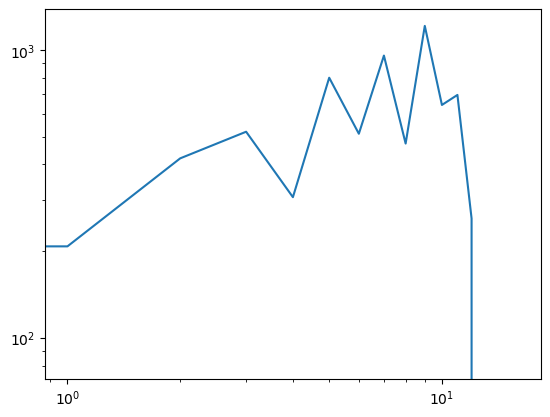

In [55]:

plt.figure(1)
plt.clf()
plt.loglog(k1d, power1d)
plt.show()

In [56]:
def power_spectrum_1d(kvec, vhat):
    N = kvec.shape[0]
    M = kvec.shape[0]//2 + 1
    powerspectr = np.zeros(M)
    k1d = np.arange(0, M)
    for i in range(M):
        k_tmp = np.sqrt(kvec**2).astype(dtype='int')
        indices = np.argwhere(k_tmp==k1d[i])
        if (indices.size != 0):
            powerspectr[i] = np.sum((vhat[indices]*np.conj(vhat[indices])).real)/(N*N)
    return powerspectr, k1d

In [57]:
from scipy.stats import truncnorm

# try 1d case
N = 128
# xx = 2.0*np.pi*np.random.uniform(size=N)
xx_uniform = 2.0*np.pi*np.linspace(0,1,N)
# xx = xx_uniform*(1.0 + 1e-2*(2.0*np.pi/N)*np.random.uniform(size=N))
# xx = 2.0*np.pi*np.linspace(0,1,N)
# xx += 0.5*( -np.sign(xx_uniform - np.pi)*(np.abs(xx_uniform - np.pi)/(np.pi))**2.2 )

# xx_1 = 2.0*np.pi*np.linspace(0,1,N//10)
# xx_2 = 2.0*np.pi*np.linspace(0+1/8,1-1/8,N//5)*(1.0 + 1e-1*np.random.uniform(size=N//5))
# xx_3 = 2.0*np.pi*np.linspace(0+1/6,1-1/6,N//4)*(1.0 + 1e-1*np.random.uniform(size=N//4)) 
# xx_4 = 2.0*np.pi*np.linspace(0+1/3,1-1/3,N-N//4-N//5-N//10)*(1.0 + 1e-1*np.random.uniform(size=N-N//4-N//5-N//10)) 
# xx = np.concatenate((xx_1, xx_2, xx_3, xx_4), axis=0)


# a, b = 0.0, 1.0
# loc, scale = 0.5, 0.2
# a_transformed, b_transformed = (a - loc) / scale, (b - loc) / scale
# xx = 2.0*np.pi*truncnorm.rvs(a_transformed, b_transformed, loc=loc, scale=scale, size=(N))

### non-uniform grid with gaussian sampling
xx = np.random.normal(loc=np.pi, scale=np.pi/2, size=(N))
xx[xx>2.0*np.pi] = xx[xx>2.0*np.pi]%(2.0*np.pi)
xx[xx<0.0] = 2.0*np.pi-(-xx[xx<0.0]%(2.0*np.pi))
### test with uniform grid
xx = 2.0*np.pi*np.linspace(0,1,N)

# a, b = 0.1, 0.9
# loc, scale = 0.5, 1e2
# a_transformed, b_transformed = (a - loc) / scale, (b - loc) / scale
# xx_2 = 2.0*np.pi*truncnorm.rvs(a_transformed, b_transformed, loc=loc, scale=scale, size=(N//2))
# a, b = 0.3, 0.7
# loc, scale = 0.5, 0.2
# a_transformed, b_transformed = (a - loc) / scale, (b - loc) / scale
# xx_3 = 2.0*np.pi*truncnorm.rvs(a_transformed, b_transformed, loc=loc, scale=scale, size=(N-N//2-N//10))

# xx = 2.0*np.pi*np.random.triangular(0,0.5,1,size=N)
# xx = xx_uniform + (1.0 + np.random.triangular(0,0.5,1,size=N))

# vec1d = np.exp(1j*xx).real + 0.0j
# vec1d_uniform = np.exp(1j*xx_uniform).real + 0.0j

def beta_profile(x, x0, rc, alpha, beta):
    r = np.abs(x - x0)
    return ((r/rc)**(-alpha))/(1 + (r/rc)**2)**(3*beta-alpha/2.)

def exp_profile(x, x0, sigma):
    r = np.abs(x - x0)
    return np.exp(-r**2/sigma**2)
                               
# vec1d = beta_profile(xx, np.pi, 2.0*np.pi, 0.8, 0.5) + 1e-2*np.exp(1j*xx).real + 0.0j
# vec1d_uniform = beta_profile(xx_uniform, np.pi, 2.0*np.pi, 0.8, 0.5) + 1e-2*np.exp(1j*xx_uniform).real + 0.0j
vec1d0 = exp_profile(xx, np.pi, np.pi/2.) + 0.0j
vec1d_uniform0 = exp_profile(xx_uniform, np.pi, np.pi/2.) + 0.0j

vec1d = exp_profile(xx, np.pi, np.pi/2.) + 0.0j
vec1d_uniform = exp_profile(xx_uniform, np.pi, np.pi/2.) + 0.0j

fluctuation = np.zeros(vec1d.shape, dtype='complex128')
fluctuation_uniform = np.zeros(vec1d.shape, dtype='complex128')

fluctuation += 1.0
fluctuation_uniform += 1.0

for i in range(4,10):
    rnd_amplitude = 0.1
    rnd_phase     = np.random.uniform(size=1)*2.0*np.pi
    rnd_phase = 0.0
    fluctuation   += rnd_amplitude*(1/i**2)*np.exp(1j*xx*i + rnd_phase).real + 0.0j
    fluctuation_uniform   += rnd_amplitude*(1/i**2)*np.exp(1j*xx_uniform*i + rnd_phase).real + 0.0j
    vec1d += vec1d0*rnd_amplitude*(1/i**2)*np.exp(1j*xx*i + rnd_phase).real + 0.0j
    vec1d_uniform += vec1d_uniform0*rnd_amplitude*(1/i**2)*np.exp(1j*xx_uniform*i + rnd_phase).real + 0.0j

k1d_target = np.fft.fftfreq(N, d=1.0/N)
vhat1d = finufft.nufft1d3(xx, vec1d, k1d_target, eps=1e-12)
vhat1d_numpy = np.fft.fft(vec1d_uniform)

powerspectr_numpy, k_shell = power_spectrum_1d(k1d_target, vhat1d_numpy)
powerspectr_finufft, k_shell = power_spectrum_1d(k1d_target, vhat1d)


## fluctuations plus 1.0

# delta_vhat1d = finufft.nufft1d3(xx, vec1d/vec1d0, k1d_target, eps=1e-12)
# delta_vhat1d_numpy = np.fft.fft(vec1d_uniform/vec1d_uniform0)

delta_vhat1d = finufft.nufft1d3(xx, fluctuation, k1d_target, eps=1e-12)
delta_vhat1d_numpy = np.fft.fft(fluctuation_uniform)

delta_powerspectr_numpy, k_shell = power_spectrum_1d(k1d_target, delta_vhat1d_numpy)
delta_powerspectr_finufft, k_shell = power_spectrum_1d(k1d_target, delta_vhat1d)

In [58]:
## for fluctuations only
# delta_vhat1d = finufft.nufft1d3(xx, vec1d/vec1d0, k1d_target, eps=1e-12)
# delta_vhat1d_numpy = np.fft.fft(vec1d_uniform/vec1d_uniform0)

ddelta_vhat1d = finufft.nufft1d3(xx, fluctuation-1.0, k1d_target, eps=1e-12)
ddelta_vhat1d_numpy = np.fft.fft(fluctuation_uniform-1.0)

ddelta_powerspectr_numpy, k_shell = power_spectrum_1d(k1d_target, ddelta_vhat1d_numpy)
ddelta_powerspectr_finufft, k_shell = power_spectrum_1d(k1d_target, ddelta_vhat1d)

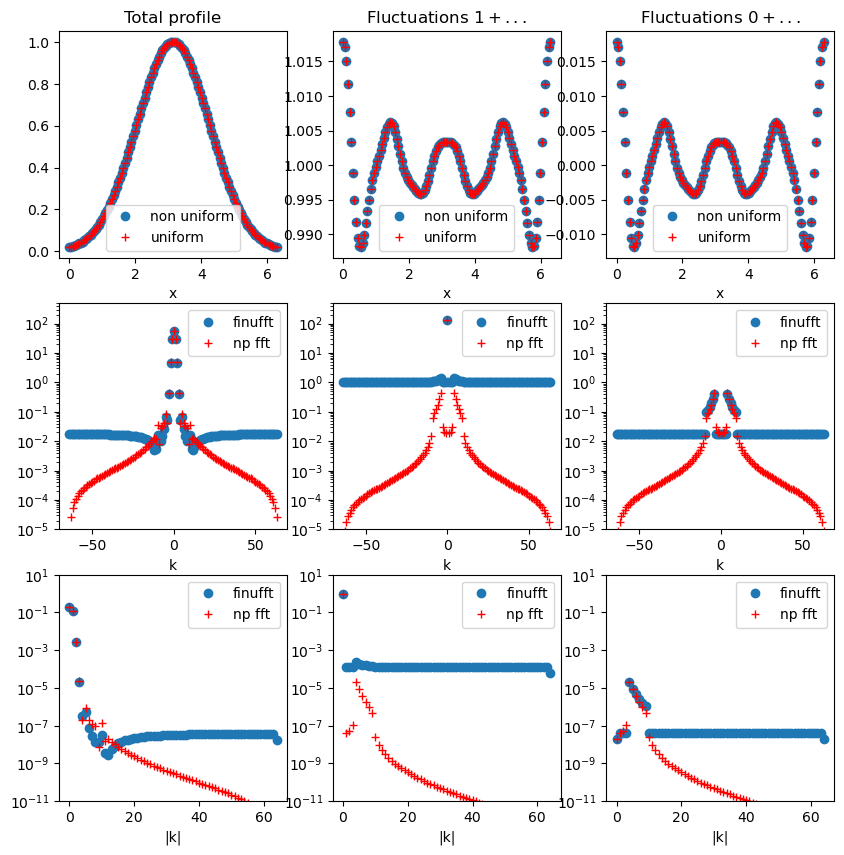

In [59]:
fig, ax = plt.subplots(3,3, figsize=(10,10))

ax[0,0].plot(xx, vec1d.real, ls='', marker='o', label='non uniform')
ax[0,0].plot(xx_uniform, vec1d_uniform.real, ls='', marker='+', color='r', label='uniform')
ax[0,0].set_xlabel('x')

ax[1,0].plot(k1d_target, np.abs(vhat1d), ls='', marker='o', label='finufft')
ax[1,0].plot(k1d_target, np.abs(vhat1d_numpy), ls='', marker='+', color='r', label='np fft')
ax[1,0].set_xlabel('k')
ax[1,0].set_yscale('log')

ax[2,0].plot(k_shell, powerspectr_finufft, ls='', marker='o', label='finufft')
ax[2,0].plot(k_shell, powerspectr_numpy, ls='', marker='+', color='r', label='np fft')
ax[2,0].set_xlabel('|k|')
ax[2,0].set_yscale('log')

ax[0,0].legend()
ax[1,0].legend()
ax[2,0].legend()

ax[0,0].set_title('Total profile')

#################################
## middle panel
#################################

ax[0,1].plot(xx, vec1d.real / vec1d0.real, ls='', marker='o', label='non uniform')
ax[0,1].plot(xx_uniform, vec1d_uniform.real / vec1d_uniform0.real, ls='', marker='+', color='r', label='uniform')
ax[0,1].set_xlabel('x')

ax[1,1].plot(k1d_target, np.abs(delta_vhat1d), ls='', marker='o', label='finufft')
ax[1,1].plot(k1d_target, np.abs(delta_vhat1d_numpy), ls='', marker='+', color='r', label='np fft')
ax[1,1].set_xlabel('k')
ax[1,1].set_yscale('log')

ax[2,1].plot(k_shell, delta_powerspectr_finufft, ls='', marker='o', label='finufft')
ax[2,1].plot(k_shell, delta_powerspectr_numpy, ls='', marker='+', color='r', label='np fft')
ax[2,1].set_xlabel('|k|')
ax[2,1].set_yscale('log')

ax[0,1].legend()
ax[1,1].legend()
ax[2,1].legend()

ax[0,1].set_title(r'Fluctuations $1 + ...$')

#################################
## right panel
#################################

ax[0,2].plot(xx, vec1d.real / vec1d0.real - 1.0, ls='', marker='o', label='non uniform')
ax[0,2].plot(xx_uniform, vec1d_uniform.real / vec1d_uniform0.real - 1.0, ls='', marker='+', color='r', label='uniform')
ax[0,2].set_xlabel('x')

ax[1,2].plot(k1d_target, np.abs(ddelta_vhat1d), ls='', marker='o', label='finufft')
ax[1,2].plot(k1d_target, np.abs(ddelta_vhat1d_numpy), ls='', marker='+', color='r', label='np fft')
ax[1,2].set_xlabel('k')
ax[1,2].set_yscale('log')

ax[2,2].plot(k_shell, ddelta_powerspectr_finufft, ls='', marker='o', label='finufft')
ax[2,2].plot(k_shell, ddelta_powerspectr_numpy, ls='', marker='+', color='r', label='np fft')
ax[2,2].set_xlabel('|k|')
ax[2,2].set_yscale('log')

ax[0,2].legend()
ax[1,2].legend()
ax[2,2].legend()

ax[0,2].set_title(r'Fluctuations $0 + ...$')


for i in range(3):
    ax[1,i].set_ylim(ymin=1e-5, ymax=5e2)
    ax[2,i].set_ylim(ymin=1e-11, ymax=1e1)


plt.show()



In [60]:
np.fft.fft(np.cos(4.0*2.0*np.pi*np.linspace(0,1,16)))

array([ 1.00000000e+00+0.j        ,  1.03314040e+00+0.2055044j ,
        1.16157353e+00+0.48113951j,  1.56729877e+00+1.04723556j,
        5.28338612e+00+5.28338612j, -1.22565439e+00-1.83432143j,
       -2.68437220e-01-0.64806478j, -5.13072028e-02-0.25793873j,
        8.88178420e-16+0.j        , -5.13072028e-02+0.25793873j,
       -2.68437220e-01+0.64806478j, -1.22565439e+00+1.83432143j,
        5.28338612e+00-5.28338612j,  1.56729877e+00-1.04723556j,
        1.16157353e+00-0.48113951j,  1.03314040e+00-0.2055044j ])

In [61]:
xx = np.random.normal(loc=np.pi, scale=np.pi/2, size=(N))
xx[xx>2.0*np.pi] = xx[xx>2.0*np.pi]%(2.0*np.pi)
xx[xx<0.0] = 2.0*np.pi-(-xx[xx<0.0]%(2.0*np.pi))

In [62]:
xx[xx<0]

array([], dtype=float64)